In [1]:
# magic command to display matplotlib plots inline within the ipython notebook webpage
%matplotlib inline

# import necessary modules
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [2]:
# create a pandas dataframe from the location data set
df = pd.read_csv('data/summer-travel-gps-full.csv')
df.head()

,lat,lon,date,city,country
0,51.481292,-0.451011,05/14/2014 09:07,West Drayton,United Kingdom
1,51.474005,-0.450999,05/14/2014 09:22,Hounslow,United Kingdom
2,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
3,51.478199,-0.446081,05/14/2014 11:24,Hounslow,United Kingdom
4,51.474146,-0.451562,05/14/2014 11:38,Hounslow,United Kingdom


In [3]:
# Q1: how to get 2 columns from the dataframe (city and country)?

df[['city', 'country']]

,city,country
0,West Drayton,United Kingdom
1,Hounslow,United Kingdom
2,Hounslow,United Kingdom
3,Hounslow,United Kingdom
4,Hounslow,United Kingdom
...,...,...
1754,Munich,Germany
1755,Munich,Germany
1756,Munich,Germany
1757,Munich,Germany


In [4]:
# Q2: how to get the first 5 rows of the "city" column?

df['city'].head(5)

0    West Drayton
1        Hounslow
2        Hounslow
3        Hounslow
4        Hounslow
Name: city, dtype: object

In [5]:
# Q3: how to use .loc to select the third row of the dataframe?

df.loc[2]

lat               51.478199
lon               -0.446081
date       05/14/2014 10:51
city               Hounslow
country      United Kingdom
Name: 2, dtype: object

In [7]:
# Q4: how to use .loc to select the first row in "country" column?

df.loc[0, 'country']

'United Kingdom'

In [8]:
# Q5: how to select the first 4 rows of ['city', 'date'] columns?

df[['city', 'date']]. head(4)

,city,date
0,West Drayton,05/14/2014 09:07
1,Hounslow,05/14/2014 09:22
2,Hounslow,05/14/2014 10:51
3,Hounslow,05/14/2014 11:24


In [9]:
# use .iloc for integer position based indexing
# Q6: how to get the value from the row in position 3 and the column in position 2

df.iloc[3,2]

'05/14/2014 11:24'

In [10]:
# Q7: how to use iloc to select every 300th row from a data set

df.iloc[::300]

,lat,lon,date,city,country
0,51.481292,-0.451011,05/14/2014 09:07,West Drayton,United Kingdom
300,41.377091,2.151175,05/20/2014 03:18,Barcelona,Spain
600,50.052338,19.946220,05/31/2014 21:10,Krakow,Poland
900,48.561181,9.059672,06/09/2014 15:12,Tübingen,Germany
1200,41.378301,2.187443,06/17/2014 16:37,Barcelona,Spain
1500,42.208201,20.735993,06/30/2014 08:27,Prizren,Kosovo


In [11]:
# load a reduced set of gps data
df = pd.read_csv('data/summer-travel-gps-simplified.csv')
df.tail()

,lat,lon,date,city,country
173,41.044556,28.983286,07/08/2014 16:44,Istanbul,Turkey
174,41.008992,28.968268,07/08/2014 20:03,Istanbul,Turkey
175,41.043487,28.985488,07/08/2014 22:18,Istanbul,Turkey
176,40.977637,28.823879,07/09/2014 09:03,Istanbul,Turkey
177,48.357110,11.791346,07/09/2014 13:20,Munich,Germany


In [12]:
# Q9: create a Series of true/false, indicating if each "city" row in the column is equal to "Munich"

df['city'].eq('Munich')

0      False
1      False
2      False
3      False
4      False
       ...  
173    False
174    False
175    False
176    False
177     True
Name: city, Length: 178, dtype: bool

In [13]:
# pandas logical operators are: | for or, & for and, ~ for not
# these must be grouped by using parentheses
# Q10: what cities were visited in spain that were not barcelona? Create a dataframe for it.

spain_not_barcelona = df[
    (df['country'].str.lower().eq('spain')) &
    (~df['city'].str.lower().eq('barcelona'))
]
spain_not_barcelona

,lat,lon,date,city,country
24,41.303911,2.105931,05/18/2014 22:35,El Prat de Llobregat,Spain
25,41.289946,2.064590,05/18/2014 23:04,Viladecans,Spain
126,41.306752,2.097624,06/12/2014 17:19,El Prat de Llobregat,Spain
127,41.304333,2.072728,06/12/2014 17:49,El Prat de Llobregat,Spain
131,41.358460,2.128701,06/13/2014 11:35,Hospitalet de Llobregat,Spain
138,41.294761,2.059722,06/20/2014 22:15,Viladecans,Spain


In [16]:
# Q11: select rows where either the city is munich, or the country is serbia

munich_or_serbia = df[
    (df['city'].str.lower().eq('munich')) |
    (df['country'].str.lower().eq('serbia'))
    ]
munich_or_serbia

,lat,lon,date,city,country
139,44.821164,20.289821,06/21/2014 01:59,Belgrade,Serbia
140,44.820414,20.463465,06/21/2014 18:44,Belgrade,Serbia
141,44.761583,19.577904,06/22/2014 07:58,Slepčević,Serbia
177,48.357110,11.791346,07/09/2014 13:20,Munich,Germany


In [17]:
# Q12: how many observations are west of the prime meridian?

west_count = (df['lon'] < 0).sum()
west_count

np.int64(24)

In [18]:
# Q13: get all rows that contain a city that starts with the letter G

g_cities = df[df['city'].str.startswith('G', na=False)]
g_cities

,lat,lon,date,city,country
62,50.273632,18.729429,06/02/2014 06:39,Gliwice,Poland
114,48.282940,8.199630,06/10/2014 13:33,Gutach,Germany
115,48.389029,8.021342,06/10/2014 13:48,Gengenbach,Germany
152,40.187825,20.079303,07/04/2014 17:42,Gjirokastër,Albania


In [19]:
# Q14: how many unique cities and countries in the dataset? 
# Also can you check missing values for the dataframe

unique_cities = df['city'].nunique()
unique_countries = df['country'].nunique()
unique_cities, unique_countries

(91, 15)

In [20]:
df.isna().sum()

lat        0
lon        0
date       0
city       0
country    0
dtype: int64

In [21]:
# Q15: group by country name and show the city names in each of the country

cities_by_country = df.groupby('country')['city'].unique()
cities_by_country

country
Albania                                                [Berat, Gjirokastër]
Bosnia and Herzegovina                                   [Sarajevo, Mostar]
Croatia                                           [Ploče, Split, Dubrovnik]
Czech Republic            [Novy Bohumin, Hranice, Prerov, Ústí nad Orlic...
Germany                   [Kümmersbruck, Winkelhaid, Kammerstein, Ellhof...
Greece                    [Kakavia, Dytiki Ellada, Peloponnese, Athens, ...
Kosovo                                                            [Prizren]
Macedonia (FYROM)                                                   [Ohrid]
Montenegro                                                          [Kotor]
Poland                    [Zendek, Silesian Voivodeship, Dabrowa Gornicz...
Portugal                  [Lisbon, Algueirão-Mem Martins, Sintra, Azambu...
Serbia                                                [Belgrade, Slepčević]
Spain                     [El Prat de Llobregat, Viladecans, Barcelona, ...
Turk

In [22]:
# load the location data set, indexed by the date field
# and, parse the dates so they're no longer strings but now rather Python datetime objects
# this lets us do date and time based operations on the data set
dt = pd.read_csv('data/summer-travel-gps-full.csv', index_col='date', parse_dates=True)
dt.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [23]:
# Q16: is the timestamp index unique? How can you use code to find it? 

dt.index.is_unique

False

In [24]:
# Q17: drop duplicate index

dt.index[dt.index.duplicated()]

DatetimeIndex(['2014-07-05 00:52:00'], dtype='datetime64[ns]', name='date', freq=None)

In [25]:
dt_nodup = dt[~dt.index.duplicated(keep='first')]
dt_nodup

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom
...,...,...,...,...
2014-07-09 13:13:00,48.356013,11.791710,Munich,Germany
2014-07-09 13:14:00,48.356529,11.792183,Munich,Germany
2014-07-09 13:17:00,48.356285,11.791710,Munich,Germany


In [26]:
# Q18: create a weekday and a weekend dataframe

df_weekday = dt[dt.index.weekday < 5]
df_weekend = dt[dt.index.weekday >= 5]

df_weekday.head(), df_weekend.head()


(                           lat       lon          city         country
 date                                                                  
 2014-05-14 09:07:00  51.481292 -0.451011  West Drayton  United Kingdom
 2014-05-14 09:22:00  51.474005 -0.450999      Hounslow  United Kingdom
 2014-05-14 10:51:00  51.478199 -0.446081      Hounslow  United Kingdom
 2014-05-14 11:24:00  51.478199 -0.446081      Hounslow  United Kingdom
 2014-05-14 11:38:00  51.474146 -0.451562      Hounslow  United Kingdom,
                            lat       lon    city   country
 date                                                      
 2014-05-17 00:09:00  38.711824 -9.137308  Lisbon  Portugal
 2014-05-17 00:39:00  38.711833 -9.137317  Lisbon  Portugal
 2014-05-17 01:09:00  38.711822 -9.137277  Lisbon  Portugal
 2014-05-17 01:39:00  38.711823 -9.137273  Lisbon  Portugal
 2014-05-17 01:54:00  38.711828 -9.137279  Lisbon  Portugal)

In [27]:
# Q19: calculate and plot the number of observations each day of the week has

counts_by_day = dt.index.day_name().value_counts()

counts_by_day

date
Saturday     269
Monday       263
Thursday     256
Wednesday    254
Tuesday      254
Sunday       245
Friday       218
Name: count, dtype: int64

In [28]:
order_day = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
counts_by_day = counts_by_day.reindex(order_day)
counts_by_day

date
Monday       263
Tuesday      254
Wednesday    254
Thursday     256
Friday       218
Saturday     269
Sunday       245
Name: count, dtype: int64

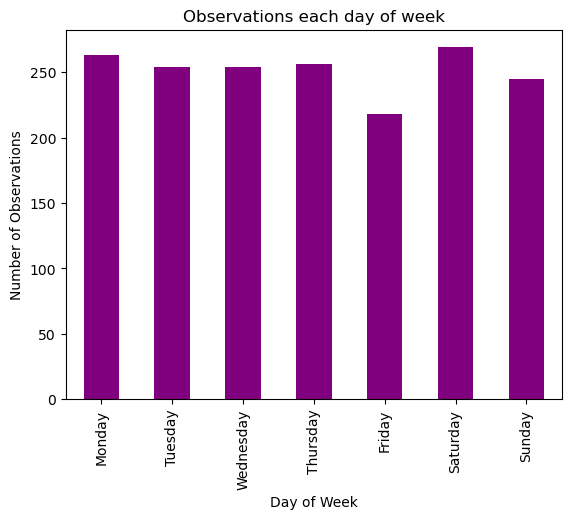

In [35]:
counts_by_day.plot(kind='bar',color='purple')
plt.xlabel('Day of Week')
plt.ylabel('Number of Observations')
plt.title('Observations each day of week')
plt.show()

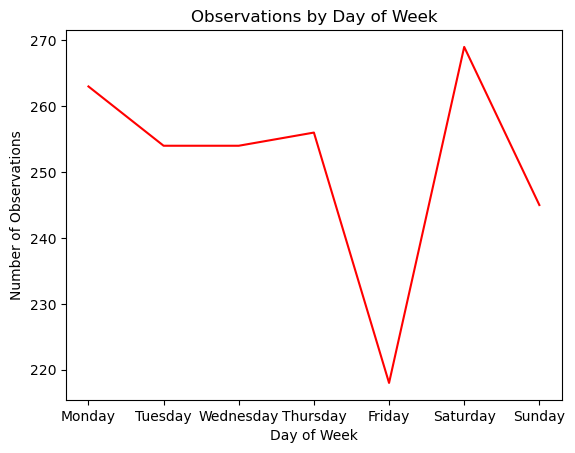

In [36]:
counts_by_day.plot(kind='line', color ='red')
plt.xlabel('Day of Week')
plt.ylabel('Number of Observations')
plt.title('Observations by Day of Week')
plt.show()